## Adult Income Data Cleaning and EDA

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs("data", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [3]:
# URLs of the official UCI Adult dataset files

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# Import SSL
import ssl

# Temporarily ignore SSL certificate verification
ssl_context = ssl._create_unverified_context()

# Import urllib
import urllib.request

# Create an opener using this SSL context
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))

# Install the opener
urllib.request.install_opener(opener)

# Download the training and test files
urllib.request.urlretrieve(train_url, "data/adult.data")
urllib.request.urlretrieve(test_url, "data/adult.test")

print("Adult dataset files downloaded successfully.")

Adult dataset files downloaded successfully.


In [4]:
# Column names of the Adult Income dataset

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

# Load training data
adult_train = pd.read_csv("data/adult.data", names=columns)

# Load test data
adult_test = pd.read_csv("data/adult.test", names=columns, skiprows=1)

In [5]:
adult_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
adult_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [7]:
# Identify the source of each dataset
adult_train["source_split"] = "train"
adult_test["source_split"] = "test"

# Combine both datasets
adult_df = pd.concat([adult_train, adult_test], ignore_index=True)
print("Combined dataset shape:", adult_df.shape)

Combined dataset shape: (48842, 16)


In [8]:
# Display first 5 rows
adult_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


In [9]:
# Check number of rows and columns
adult_df.shape

(48842, 16)

In [10]:
# Display all columns names
adult_df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'source_split'],
      dtype='str')

In [11]:
# Check data types of all columns
adult_df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
source_split        str
dtype: object

In [12]:
# Check unique values in workclass

adult_df["workclass"].unique()

<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

In [13]:
# Remove extra spaces from text columns

for column in adult_df.select_dtypes(include="object").columns:
    adult_df[column] = adult_df[column].str.strip()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9416\3681888695.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in adult_df.select_dtypes(include="object").columns:


In [14]:
adult_df["workclass"].unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [15]:
# Replace '?' with missing values
adult_df = adult_df.replace("?", np.nan)

In [16]:
# Check missing values 
adult_df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
source_split         0
dtype: int64

In [17]:
# Check the number of duplicate rows
duplicate_count = adult_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 29


In [18]:
# Check basic statistics of numerical columns
adult_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [19]:
# Check the different income values
adult_df["income"].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [20]:
adult_df["income"] = adult_df["income"].str.replace(".", "", regex=False)
adult_df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [21]:
# Fill missing categorical values
adult_df["workclass"] = adult_df["workclass"].fillna("Unknown")
adult_df["occupation"] = adult_df["occupation"].fillna("Unknown")
adult_df["native_country"] = adult_df["native_country"].fillna("Unknown")

# Check missing values again
adult_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
source_split      0
dtype: int64

In [ ]:
# Step 5.16 — Check numeric data types
# Check data types of numeric columns
print(adult_df[["age", "fnlwgt", "education_num",
                "capital_gain", "capital_loss",
                "hours_per_week"]].dtypes)

age               int64
fnlwgt            int64
education_num     int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
dtype: object


In [ ]:
# Step 5.17 — Check for impossible numeric values
# Check the minimum and maximum values of important numeric columns
print("Age:", adult_df["age"].min(), "to", adult_df["age"].max())
print("Education number:", adult_df["education_num"].min(), "to", adult_df["education_num"].max())
print("Hours per week:", adult_df["hours_per_week"].min(), "to", adult_df["hours_per_week"].max())

Age: 17 to 90
Education number: 1 to 16
Hours per week: 1 to 99


In [ ]:
# Step 5.18 — Create Age Groups
# Create age groups
adult_df["age_group"] = pd.cut(
    adult_df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

# Check the number of people in each age group
adult_df["age_group"].value_counts().sort_index()

age_group
18-25     9627
26-35    12719
36-45    11952
46-55     8296
56-65     4445
66+       1803
Name: count, dtype: int64

In [ ]:
# Step 5.19 — Create Work-Hour Groups
# Create working-hour groups
adult_df["hours_group"] = pd.cut(
    adult_df["hours_per_week"],
    bins=[0, 20, 40, 60, 100],
    labels=["0-20", "21-40", "41-60", "61+"]
)

# Check the number of people in each group
adult_df["hours_group"].value_counts().sort_index

<bound method Series.sort_index of hours_group
21-40    30037
41-60    12676
0-20      4453
61+       1676
Name: count, dtype: int64>

In [ ]:
# Step 5.20 — Create Net Capital Gain
# Create net capital gain
adult_df["net_capital_gain"] = (
    adult_df["capital_gain"] - adult_df["capital_loss"]
)

# Check the first 5 values
adult_df[["capital_gain", "capital_loss", "net_capital_gain"]].head()

,capital_gain,capital_loss,net_capital_gain
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [ ]:
# Step 5.21 — Final cleaning check
# Check the final number of rows and columns
print("Shape:", adult_df.shape)

# Display all column names
print("\nColumns:")
print(adult_df.columns.tolist())

Shape: (48842, 19)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'source_split', 'age_group', 'hours_group', 'net_capital_gain']


In [ ]:
# Step 5.22 — Create high_income
# Convert income into a numeric column
# 0 = income <=50K
# 1 = income >50K

adult_df["high_income"] = adult_df["income"].map({"<=50K": 0,">50K": 1})

# Check the result
adult_df["high_income"].value_counts()

high_income
0    37155
1    11687
Name: count, dtype: int64

In [ ]:
# Step 5.23 — Calculate Income Percentage
# Calculate the percentage of each income group
income_percentage = adult_df["income"].value_counts(normalize=True) * 100
print(income_percentage)

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


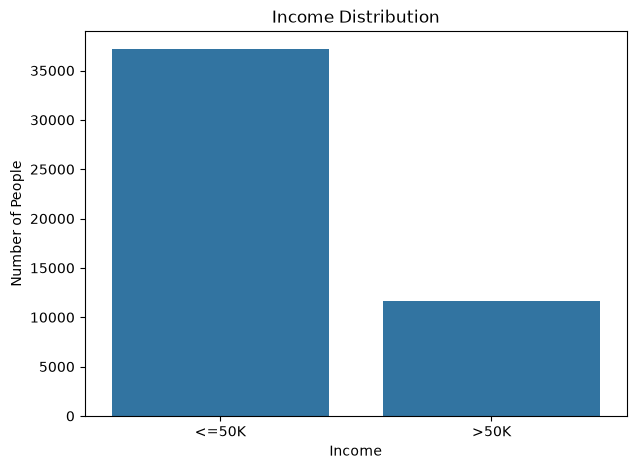

In [ ]:
# Step 6.1 — Visualize Income Distribution
# Plot the income distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=adult_df, x="income")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of People")
plt.show()

In [ ]:
# Step 6.2 — Income by Education
# Calculate the percentage of high-income people by education level
education_income = adult_df.groupby("education")["high_income"].mean() * 100

# Sort from highest to lowest
education_income = education_income.sort_values(ascending=False)
print(education_income)

education
Prof-school     73.980815
Doctorate       72.558923
Masters         54.911554
Bachelors       41.283489
Assoc-acdm      25.796377
Assoc-voc       25.327511
Some-college    18.964883
HS-grad         15.857831
12th             7.305936
7th-8th          6.492147
10th             6.263499
9th              5.423280
5th-6th          5.304519
11th             5.077263
1st-4th          3.238866
Preschool        1.204819
Name: high_income, dtype: float64


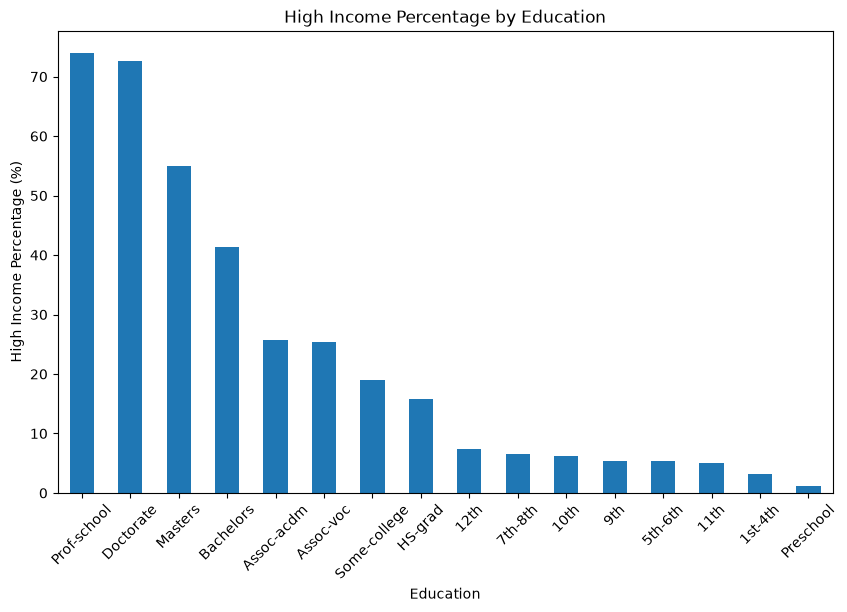

In [ ]:
# Step 6.3 — Education vs High Income
# Plot high-income percentage by education level

plt.figure(figsize=(10, 6))
education_income.plot(kind="bar")
plt.title("High Income Percentage by Education")
plt.xlabel("Education")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 6.4 — Income by Occupation
# Calculate the percentage of high-income people by occupation
occupation_income = adult_df.groupby("occupation")["high_income"].mean() * 100

# Sort from highest to lowest
occupation_income = occupation_income.sort_values(ascending=False)
print(occupation_income)

occupation
Exec-managerial      47.781794
Prof-specialty       45.106935
Armed-Forces         33.333333
Protective-serv      31.332655
Tech-support         29.045643
Sales                26.798692
Craft-repair         22.627618
Transport-moving     20.424628
Adm-clerical         13.687400
Machine-op-inspct    12.309729
Farming-fishing      11.610738
Unknown               9.433962
Handlers-cleaners     6.660232
Other-service         4.143815
Priv-house-serv       1.239669
Name: high_income, dtype: float64


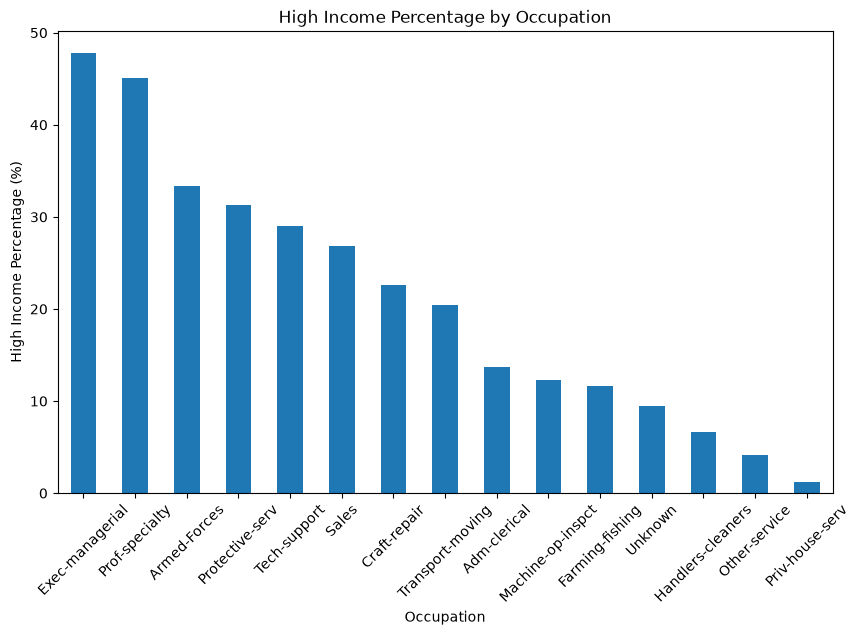

In [ ]:
# Step 6.5 — Occupation vs High Income
# Plot high-income percentage by occupation

plt.figure(figsize=(10, 6))
occupation_income.plot(kind="bar")
plt.title("High Income Percentage by Occupation")
plt.xlabel("Occupation")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 6.6 — Age Group vs High Income
# Calculate the percentage of high-income people by age group
age_income = adult_df.groupby("age_group", observed=True)["high_income"].mean() * 100

# Display the result
print(age_income)

age_group
18-25     1.755479
26-35    18.704301
36-45    34.563253
46-55    39.235776
56-65    31.406074
66+      19.800333
Name: high_income, dtype: float64


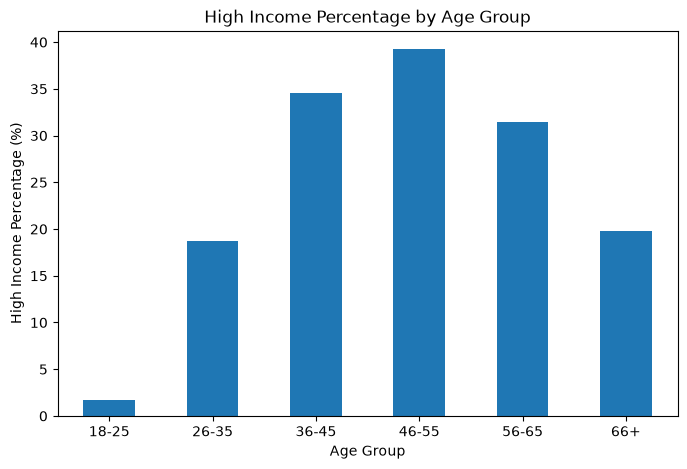

In [ ]:
# Step 6.7 — Age Group vs High Income
# Plot high-income percentage by age group

plt.figure(figsize=(8, 5))
age_income.plot(kind="bar")
plt.title("High Income Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Step 6.8 — Workclass vs High Income
# Calculate the percentage of high-income people by workclass
workclass_income = adult_df.groupby("workclass")["high_income"].mean() * 100

# Sort from highest to lowest
workclass_income = workclass_income.sort_values(ascending=False)
print(workclass_income)

workclass
Self-emp-inc        55.339233
Federal-gov         39.175978
Local-gov           29.559949
Self-emp-not-inc    27.887105
State-gov           26.754165
Private             21.786704
Without-pay          9.523810
Unknown              9.467667
Never-worked         0.000000
Name: high_income, dtype: float64


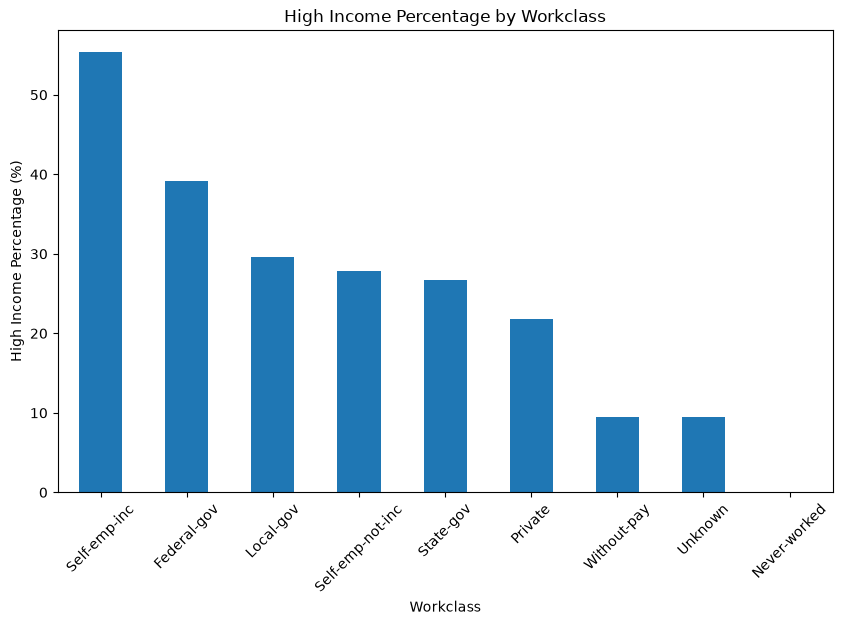

In [ ]:
# Step 6.9 — Workclass vs High Income
# Plot high-income percentage by workclass

plt.figure(figsize=(10, 6))
workclass_income.plot(kind="bar")
plt.title("High Income Percentage by Workclass")
plt.xlabel("Workclass")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=45)
plt.show()

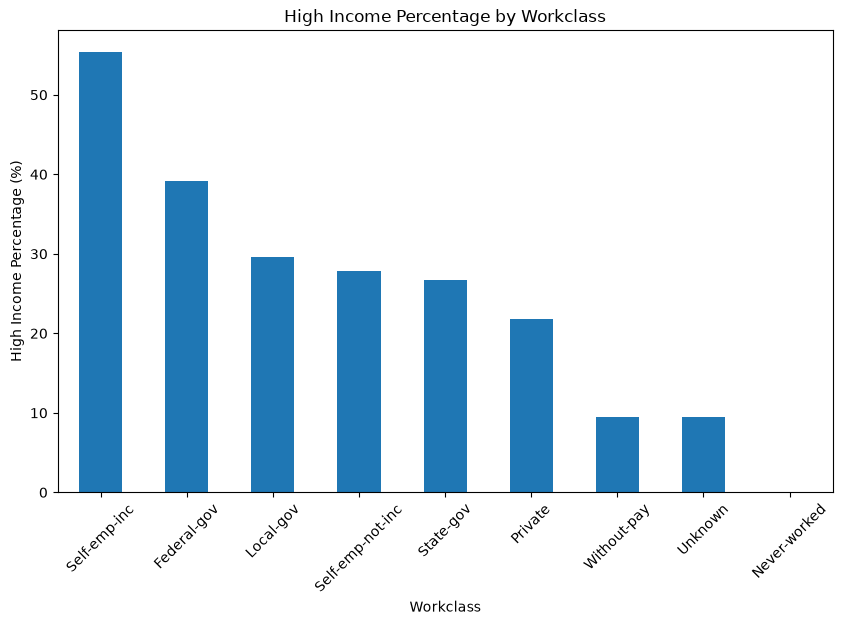

In [ ]:
# Step 6.9 — Workclass vs High Income Chart
# Plot high-income percentage by workclass
plt.figure(figsize=(10, 6))
workclass_income.plot(kind="bar")
plt.title("High Income Percentage by Workclass")
plt.xlabel("Workclass")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 6.10 — Sex vs High Income
# Calculate high-income percentage by sex
sex_income = adult_df.groupby("sex")["high_income"].mean() * 100

# Sort from highest to lowest
sex_income = sex_income.sort_values(ascending=False)
print(sex_income)

sex
Male      30.376723
Female    10.925148
Name: high_income, dtype: float64


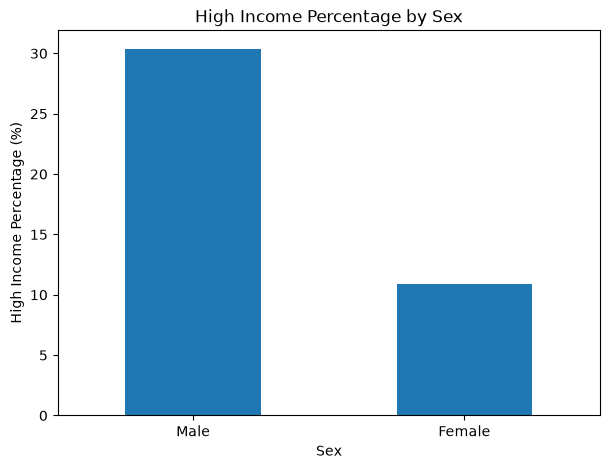

In [ ]:
# Step 6.11 — Sex vs High Income Bar Chart
# Plot high-income percentage by sex
plt.figure(figsize=(7, 5))
sex_income.plot(kind="bar")
plt.title("High Income Percentage by Sex")
plt.xlabel("Sex")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [42]:
# Step 6.12 — Working Hours vs High Income
# Calculate high-income percentage by working hours group

hours_income = adult_df.groupby("hours_group",observed=True)["high_income"].mean() * 100
print(hours_income)

hours_group
0-20      6.759488
21-40    18.790159
41-60    40.572736
61+      35.739857
Name: high_income, dtype: float64


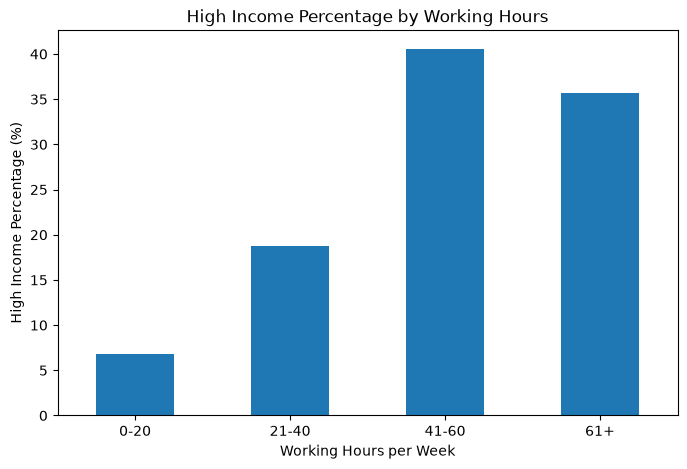

In [43]:
# Step 6.13 — Working Hours vs High Income Chart
# Plot high-income percentage by working hours group

plt.figure(figsize=(8, 5))
hours_income.plot(kind="bar")
plt.title("High Income Percentage by Working Hours")
plt.xlabel("Working Hours per Week")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=0)
plt.show()

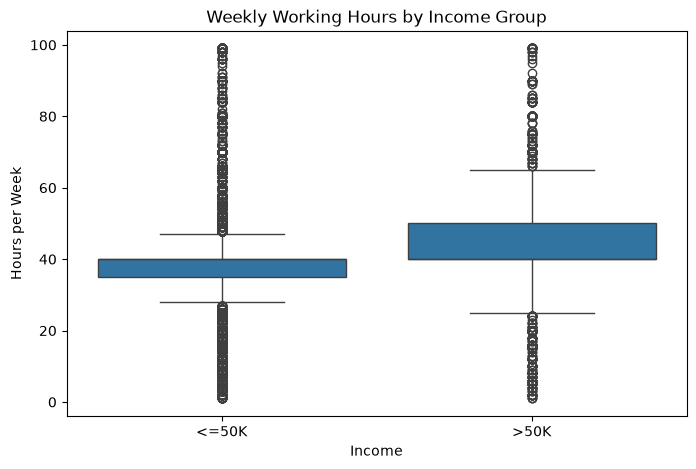

In [44]:
# Step 6.14 — Weekly Working Hours Distribution
# Compare weekly working hours for different income groups

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=adult_df,
    x="income",
    y="hours_per_week"
)
plt.title("Weekly Working Hours by Income Group")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

In [45]:
# Step 6.15 — Education Number vs High Income
# Calculate high-income percentage by education number

education_num_income = adult_df.groupby("education_num")["high_income"].mean() * 100
print(education_num_income)

education_num
1      1.204819
2      3.238866
3      5.304519
4      6.492147
5      5.423280
6      6.263499
7      5.077263
8      7.305936
9     15.857831
10    18.964883
11    25.327511
12    25.796377
13    41.283489
14    54.911554
15    73.980815
16    72.558923
Name: high_income, dtype: float64


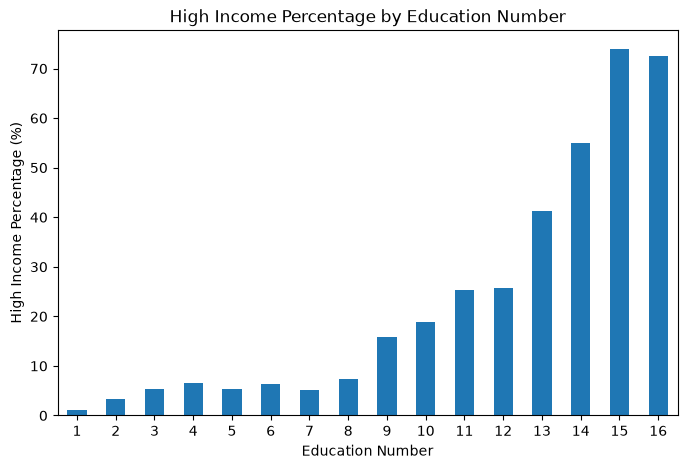

In [46]:
# Step 6.16 — Education Number vs High Income Chart
# Plot high-income percentage by education number

plt.figure(figsize=(8, 5))
education_num_income.plot(kind="bar")
plt.title("High Income Percentage by Education Number")
plt.xlabel("Education Number")
plt.ylabel("High Income Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [47]:
# Step 6.17 — Overall Income Summary
# Create an overall income summary table

income_summary = adult_df["income"].value_counts().reset_index()
income_summary.columns = ["Income", "Count"]
income_summary["Percentage"] = (income_summary["Count"] / len(adult_df) * 100)
print(income_summary)

  Income  Count  Percentage
0  <=50K  37155   76.071823
1   >50K  11687   23.928177


In [48]:
# Step 6.18 — Create a Summary Table for Education
# Create education summary table

education_summary = adult_df.groupby("education").agg(
    Total_People=("high_income", "count"),
    High_Income_Percentage=("high_income", "mean")
)

education_summary["High_Income_Percentage"] = (
    education_summary["High_Income_Percentage"] * 100
)

education_summary = education_summary.sort_values(
    "High_Income_Percentage",
    ascending=False
)

print(education_summary)

              Total_People  High_Income_Percentage
education                                         
Prof-school            834               73.980815
Doctorate              594               72.558923
Masters               2657               54.911554
Bachelors             8025               41.283489
Assoc-acdm            1601               25.796377
Assoc-voc             2061               25.327511
Some-college         10878               18.964883
HS-grad              15784               15.857831
12th                   657                7.305936
7th-8th                955                6.492147
10th                  1389                6.263499
9th                    756                5.423280
5th-6th                509                5.304519
11th                  1812                5.077263
1st-4th                247                3.238866
Preschool               83                1.204819


In [49]:
# Step 6.19 — Occupation Summary Table
# Create occupation summary table

occupation_summary = adult_df.groupby("occupation").agg(
    Total_People=("high_income", "count"),
    High_Income_Percentage=("high_income", "mean")
)

occupation_summary["High_Income_Percentage"] = (
    occupation_summary["High_Income_Percentage"] * 100
)

occupation_summary = occupation_summary.sort_values(
    "High_Income_Percentage",
    ascending=False
)

print(occupation_summary)

                   Total_People  High_Income_Percentage
occupation                                             
Exec-managerial            6086               47.781794
Prof-specialty             6172               45.106935
Armed-Forces                 15               33.333333
Protective-serv             983               31.332655
Tech-support               1446               29.045643
Sales                      5504               26.798692
Craft-repair               6112               22.627618
Transport-moving           2355               20.424628
Adm-clerical               5611               13.687400
Machine-op-inspct          3022               12.309729
Farming-fishing            1490               11.610738
Unknown                    2809                9.433962
Handlers-cleaners          2072                6.660232
Other-service              4923                4.143815
Priv-house-serv             242                1.239669


In [50]:
# Step 6.20 — Age Group Summary Table
# Create age group summary table

age_summary = adult_df.groupby(
    "age_group",
    observed=True
).agg(
    Total_People=("high_income", "count"),
    High_Income_Percentage=("high_income", "mean")
)

age_summary["High_Income_Percentage"] = (
    age_summary["High_Income_Percentage"] * 100
)
print(age_summary)

           Total_People  High_Income_Percentage
age_group                                      
18-25              9627                1.755479
26-35             12719               18.704301
36-45             11952               34.563253
46-55              8296               39.235776
56-65              4445               31.406074
66+                1803               19.800333


In [51]:
# Step 6.21 — Workclass Summary Table
# Create workclass summary table

workclass_summary = adult_df.groupby("workclass").agg(
    Total_People=("high_income", "count"),
    High_Income_Percentage=("high_income", "mean")
)

workclass_summary["High_Income_Percentage"] = (
    workclass_summary["High_Income_Percentage"] * 100
)

workclass_summary = workclass_summary.sort_values(
    "High_Income_Percentage",
    ascending=False
)

print(workclass_summary)

                  Total_People  High_Income_Percentage
workclass                                             
Self-emp-inc              1695               55.339233
Federal-gov               1432               39.175978
Local-gov                 3136               29.559949
Self-emp-not-inc          3862               27.887105
State-gov                 1981               26.754165
Private                  33906               21.786704
Without-pay                 21                9.523810
Unknown                   2799                9.467667
Never-worked                10                0.000000


In [53]:
# Step 6.22 — Working Hours Summary Table
# Create working hours summary table

hours_summary = adult_df.groupby(
    "hours_group",
    observed=True
).agg(
    Total_People=("high_income", "count"),
    High_Income_Percentage=("high_income", "mean")
)

hours_summary["High_Income_Percentage"] = (
    hours_summary["High_Income_Percentage"] * 100
)

print(hours_summary)

             Total_People  High_Income_Percentage
hours_group                                      
0-20                 4453                6.759488
21-40               30037               18.790159
41-60               12676               40.572736
61+                  1676               35.739857


In [ ]:
# Step 6.23 — Final Missing Value Check
# Check missing values after all cleaning steps

missing_values = adult_df.isnull().sum()
print(missing_values)

age                 0
workclass           0
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation          0
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country      0
income              0
source_split        0
age_group           0
hours_group         0
net_capital_gain    0
high_income         0
dtype: int64


In [55]:
# Step 6.24 — Final Duplicate Check
# Final duplicate check

duplicate_count = adult_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 29


In [ ]:
# Step 6.25 — Final Dataset Shape Check
# Check final dataset shape

print("Final dataset shape:", adult_df.shape)
print("Number of rows:", adult_df.shape[0])
print("Number of columns:", adult_df.shape[1])

Final dataset shape: (48842, 20)
Number of rows: 48842
Number of columns: 20


In [57]:
# Step 6.26 — Save Final Cleaned CSV
# Save the final cleaned dataset

adult_df.to_csv("data/adult_income_cleaned.csv",index=False)
print("Cleaned dataset saved successfully.")
print("File: data/adult_income_cleaned.csv")

Cleaned dataset saved successfully.
File: data/adult_income_cleaned.csv
